In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import re
import os
import random
import matplotlib.image as mpimg
import kagglehub
from google.colab import drive

In [ ]:
drive.mount('/content/drive')
print("Đang tải dữ liệu từ Kaggle...")
path = kagglehub.dataset_download("maitam/vietnamese-traffic-signs")


Mounted at /content/drive
Đang tải dữ liệu từ Kaggle...


100%|██████████| 757M/757M [00:29<00:00, 27.0MB/s]

Extracting files...


In [ ]:
path_dsComplete = '/content/drive/MyDrive/VQA_TrafficSign_Dataset/vqa_dataset_complete.csv'

In [ ]:
# Cài đặt style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# 1. Đọc dữ liệu
df = pd.read_csv(path_dsComplete)

# 2. Xóa cột group_id
if 'group_id' in df.columns:
    df = df.drop(columns=['group_id'])
    print("Đã xóa cột 'group_id'.")

# 3. In thống kê cơ bản
print(f"Tổng số bộ (triplets) QA: {len(df)}")
print(f"Số lượng ảnh duy nhất: {df['image_name'].nunique()}")
print(f"Số câu hỏi trung bình trên mỗi ảnh: {len(df) / df['image_name'].nunique():.2f}")

display(df.head(10))

Đã xóa cột 'group_id'.
Tổng số bộ (triplets) QA: 2608
Số lượng ảnh duy nhất: 386
Số câu hỏi trung bình trên mỗi ảnh: 6.76


,image_name,question,answer,type
0,0675.jpg,Biển báo trên cùng là biển gì?,Biển cấm rẽ phải và quay đầu.,Identity
1,0675.jpg,Biển báo cấm có hình dạng và màu sắc gì?,"Hình tròn, viền đỏ, nền trắng.",Attribute
2,0675.jpg,Trong ảnh có biển báo cấm rẽ trái không?,"Có, nằm ở phía xa.",Yes_No
3,0675.jpg,Có bao nhiêu biển báo giao thông xuất hiện tro...,Có 3 biển báo.,Counting
4,0675.jpg,Biển cấm rẽ phải nằm ở vị trí nào?,Nằm treo trên giá long môn phía trên.,Spatial
5,1842.jpg,Đây là loại biển báo gì?,Biển báo cấm xe sơ-mi rơ-moóc.,Identity
6,1842.jpg,Biển báo có hiệu lực trong khung giờ nào?,Từ 6:00 đến 22:00.,Attribute
7,1842.jpg,Có biển báo cấm xe sơ-mi rơ-moóc trong ảnh không?,"Có, biển báo nằm ở trung tâm ảnh.",Yes_No
8,1842.jpg,Có bao nhiêu biển báo giao thông trong ảnh?,Chỉ có một biển báo chính.,Counting
9,1842.jpg,Biển báo nằm ở vị trí nào so với cái cây?,Biển báo nằm phía dưới tán cây.,Spatial


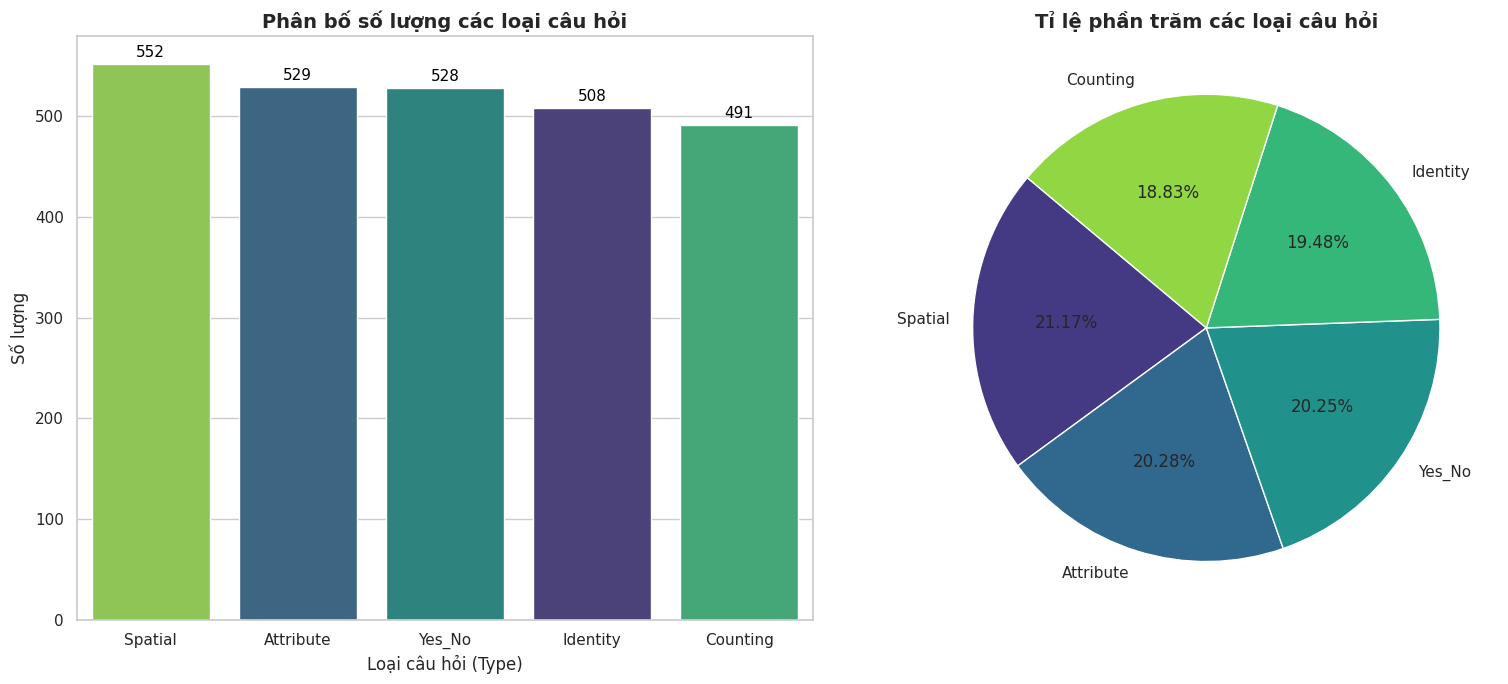

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# 1. Biểu đồ cột (Bar Chart)
sns.countplot(data=df, x='type', hue='type', palette='viridis',
              order=df['type'].value_counts().index, ax=ax1, legend=False)

ax1.set_title("Phân bố số lượng các loại câu hỏi", fontsize=14, fontweight='bold')
ax1.set_xlabel("Loại câu hỏi (Type)", fontsize=12)
ax1.set_ylabel("Số lượng", fontsize=12)

# Thêm số lượng cụ thể lên trên mỗi cột
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

# 2. Biểu đồ tròn (Pie Chart)
type_counts = df['type'].value_counts()
ax2.pie(type_counts, labels=type_counts.index, autopct='%1.2f%%',
        startangle=140, colors=sns.color_palette('viridis', len(type_counts)))
ax2.set_title("Tỉ lệ phần trăm các loại câu hỏi", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

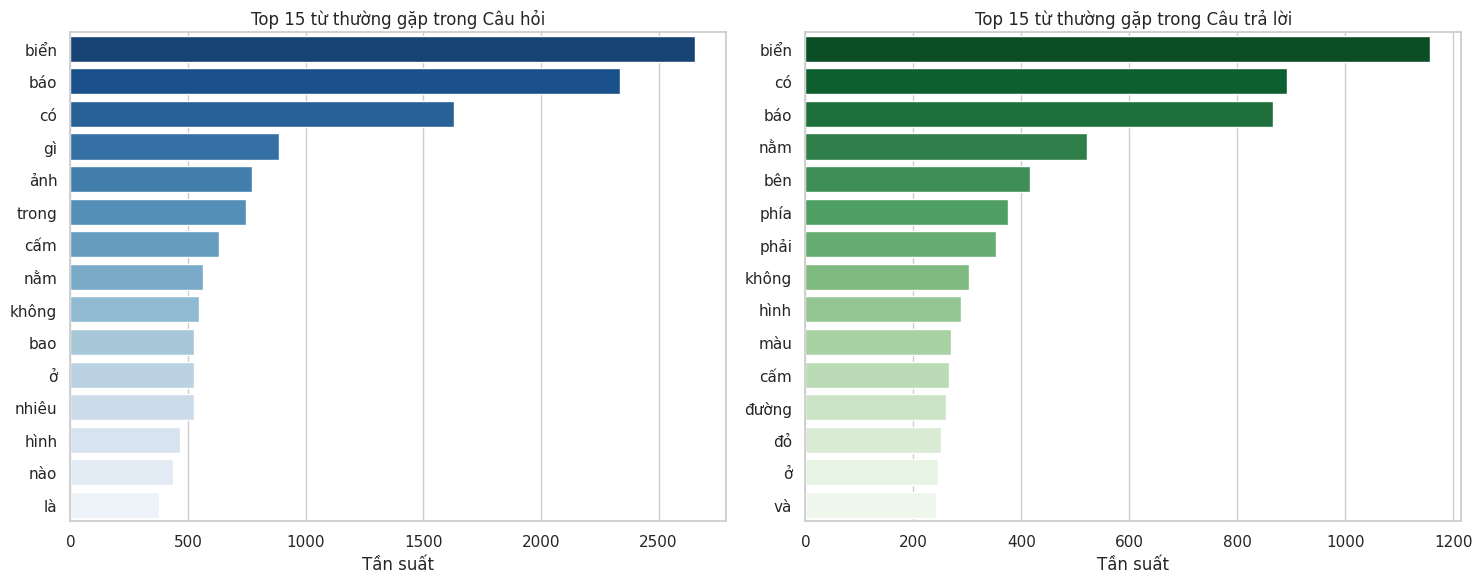

In [ ]:
def get_top_words(text_series, top_n=15):
    # Nối tất cả các câu, chuyển chữ thường, xóa dấu câu cơ bản
    all_text = ' '.join(text_series.astype(str).tolist()).lower()
    all_text = re.sub(r'[^\w\s]', '', all_text)
    words = all_text.split()
    return Counter(words).most_common(top_n)

top_q_words = get_top_words(df['question'])
top_a_words = get_top_words(df['answer'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ từ vựng câu hỏi
sns.barplot(x=[w[1] for w in top_q_words], y=[w[0] for w in top_q_words], hue=[w[0] for w in top_q_words], ax=axes[0], palette='Blues_r', legend=False)
axes[0].set_title('Top 15 từ thường gặp trong Câu hỏi')
axes[0].set_xlabel('Tần suất')

# Biểu đồ từ vựng câu trả lời
sns.barplot(x=[w[1] for w in top_a_words], y=[w[0] for w in top_a_words], hue=[w[0] for w in top_a_words], ax=axes[1], palette='Greens_r', legend=False)
axes[1].set_title('Top 15 từ thường gặp trong Câu trả lời')
axes[1].set_xlabel('Tần suất')

plt.tight_layout()
plt.show()

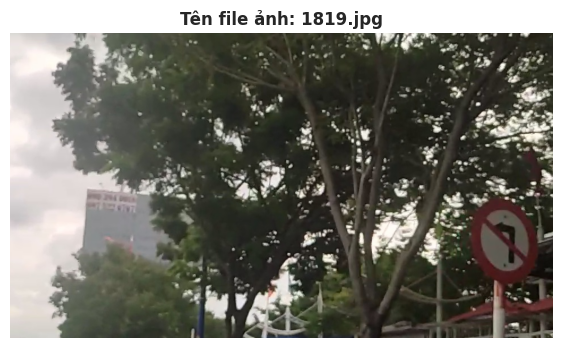

--- BỘ CÂU HỎI CHO ẢNH NÀY (5 câu) ---
[Identity] Q: Đây là loại biển báo gì?
   -> A: Biển báo cấm rẽ trái.

[Attribute] Q: Biển báo cấm rẽ trái có hình dạng gì?
   -> A: Hình tròn.

[Yes_No] Q: Có biển báo cấm rẽ phải trong ảnh không?
   -> A: Không.

[Counting] Q: Có bao nhiêu biển báo giao thông trong ảnh?
   -> A: Một biển báo.

[Spatial] Q: Biển báo nằm ở vị trí nào trong ảnh?
   -> A: Góc phải bên dưới.



In [ ]:
# THIẾT LẬP ĐƯỜNG DẪN ẢNH
# Lấy biến path từ lệnh kagglehub của bạn (nếu chạy chung notebook)
# Hoặc thay bằng chuỗi đường dẫn cứng nếu cần.
# Ví dụ: DATA_DIR = f"{path}/archive/images/"
DATA_DIR = f"{path}/archive/images/"

# Chọn ngẫu nhiên 1 ảnh từ dataset
random_img = random.choice(df['image_name'].unique())
img_path = os.path.join(DATA_DIR, random_img)

if os.path.exists(img_path):
    img = mpimg.imread(img_path)

    plt.figure(figsize=(7, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Tên file ảnh: {random_img}", fontweight='bold')
    plt.show()

    # Lọc và in các cặp QA của ảnh này
    qa_subset = df[df['image_name'] == random_img]
    print(f"--- BỘ CÂU HỎI CHO ẢNH NÀY ({len(qa_subset)} câu) ---")
    for idx, row in qa_subset.iterrows():
        print(f"[{row['type']}] Q: {row['question']}")
        print(f"   -> A: {row['answer']}\n")
else:
    print(f"❌ Không tìm thấy ảnh tại: {img_path}")
    print("Vui lòng kiểm tra lại biến DATA_DIR xem đã trỏ đúng thư mục /archive/images/ chưa nhé.")

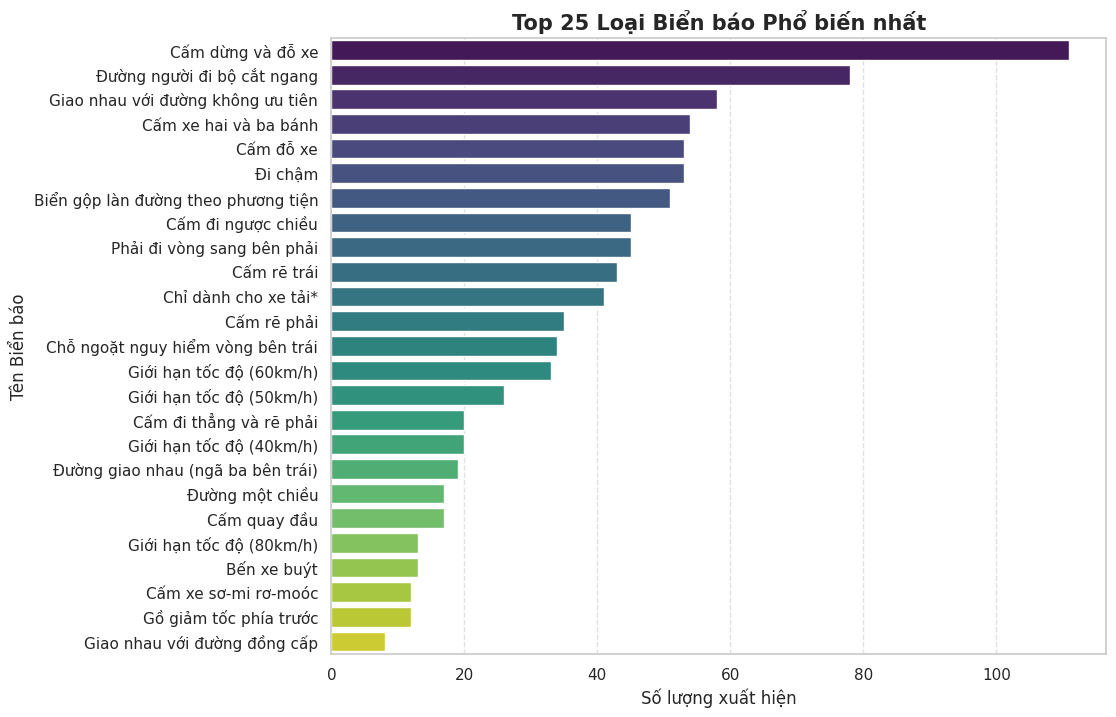

Tổng số nhãn biển báo đã trích xuất: 988
Số lượng loại biển báo khác nhau: 44


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths
LABEL_DIR = os.path.join(path, 'archive/labels')
CLASSES_FILE = os.path.join(path, 'archive/classes_vie.txt')

# 2. Load Class Names
class_names = {}
if os.path.exists(CLASSES_FILE):
    with open(CLASSES_FILE, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            name = line.strip()
            if name:
                class_names[str(idx)] = name
else:
    print(f"❌ Không tìm thấy file class tại: {CLASSES_FILE}")

all_sign_ids = []
unique_images = df['image_name'].unique()

# 3. Extract IDs from .txt files
for img_name in unique_images:
    label_file = os.path.splitext(img_name)[0] + '.txt'
    label_path = os.path.join(LABEL_DIR, label_file)

    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    all_sign_ids.append(parts[0])

# 4. Create a DataFrame and Map Names
sign_counts = pd.Series(all_sign_ids).value_counts().reset_index()
sign_counts.columns = ['Sign_ID', 'Count']
sign_counts['Sign_Name'] = sign_counts['Sign_ID'].map(class_names).fillna("Unknown")

# 5. Visualization
plt.figure(figsize=(10, 8))
sns.barplot(data=sign_counts.head(25), x='Count', y='Sign_Name', hue='Sign_Name', palette='viridis', legend=False)
plt.title('Top 25 Loại Biển báo Phổ biến nhất', fontsize=15, fontweight='bold')
plt.xlabel('Số lượng xuất hiện', fontsize=12)
plt.ylabel('Tên Biển báo', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

print(f"Tổng số nhãn biển báo đã trích xuất: {len(all_sign_ids)}")
print(f"Số lượng loại biển báo khác nhau: {len(sign_counts)}")